# Lab2: Mathematical Foundations of Deep Learning

In this lab, we will experimentally verify the mathematical theories discussed in our lecture using Python and NumPy. We will explore how geometry collapses in high dimensions, visualize the transformations of weight matrices, and understand why non-linearities and advanced optimizers (like Momentum and Adam) are strictly necessary.

In [12]:
!pip install ipympl


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [21]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

## 1. The Curse of Dimensionality: The Hypersphere Shell

We will calculate the volume of a hypersphere of radius $R=1$ as the dimensions $n$ increase. 
$$V_n(R) = \frac{\pi^{n/2}}{\Gamma(n/2 + 1)} R^n$$


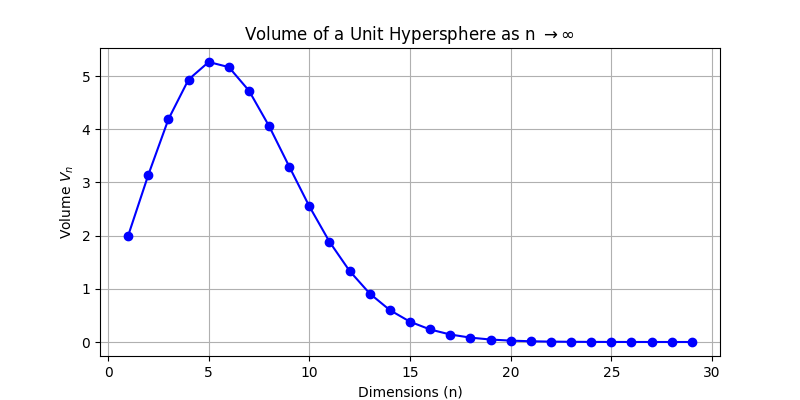

In [14]:
dimensions = np.arange(1, 30)
R = 1.0
volumes = []

for n in dimensions:
    # Calculate the volume using the gamma function from scipy
    V_n = (np.pi**(n / 2) / gamma(n / 2 + 1)) * (R**n)
    volumes.append(V_n)

plt.figure(figsize=(8, 4))
plt.plot(dimensions, volumes, marker='o', color='b')
plt.title("Volume of a Unit Hypersphere as n $\\to \\infty$")
plt.xlabel("Dimensions (n)")
plt.ylabel("Volume $V_n$")
plt.grid(True)
plt.show()

## 2. The Soap Bubble Paradox and Distance Collapse

If all data in high dimensions lives on the "shell" (like a soap bubble), what happens to distances? 
We will generate random points in a 10,000-dimensional space and calculate two things:
1. Their Euclidean distance from the origin (center).
2. Their Euclidean distance from each other.

You will see that they are all roughly the same distance from the center, AND they are all roughly the exact same distance from each other!

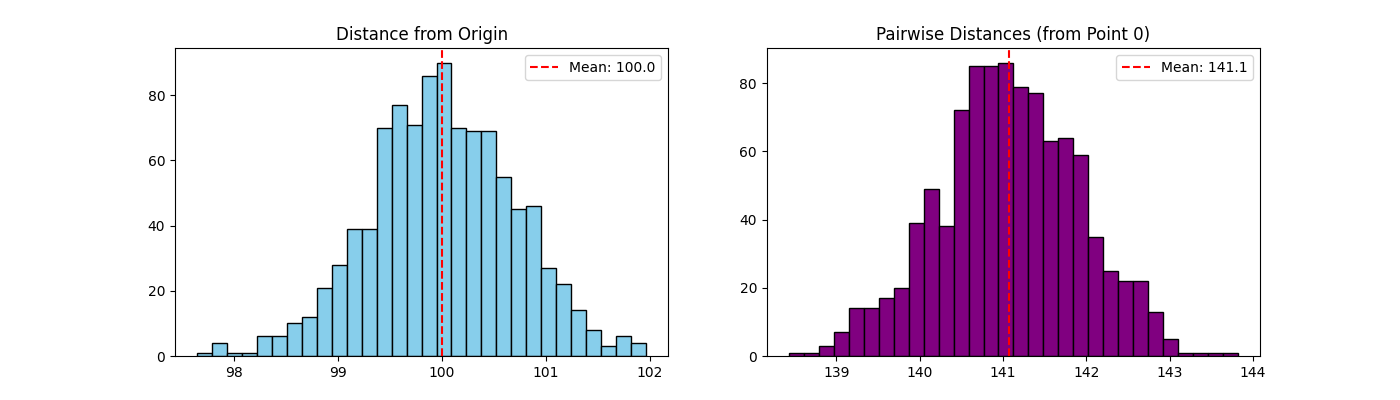

In [17]:
d = 10000  # High dimensions
num_points = 1000

# Generate random points (Gaussian distribution)
points = np.random.normal(0, 1, (num_points, d))

# 1. Calculate distance from the origin (0, 0, ..., 0)
origin = np.zeros(d)
dist_from_origin = np.linalg.norm(points - origin, axis=1) 

# 2. Calculate pairwise distances (distance of all points from the first point)
pairwise_distances = np.linalg.norm(points - points[0], axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(dist_from_origin, bins=30, color='skyblue', edgecolor='black')
ax1.set_title("Distance from Origin")
ax1.axvline(np.mean(dist_from_origin), color='red', linestyle='dashed', label=f'Mean: {np.mean(dist_from_origin):.1f}')
ax1.legend()

ax2.hist(pairwise_distances[1:], bins=30, color='purple', edgecolor='black')
ax2.set_title("Pairwise Distances (from Point 0)")
ax2.axvline(np.mean(pairwise_distances[1:]), color='red', linestyle='dashed', label=f'Mean: {np.mean(pairwise_distances[1:]):.1f}')
ax2.legend()

plt.show()

## 3. Weight Matrices and the Geometry of SVD

Every weight matrix $W$ performs a linear transformation. Through Singular Value Decomposition ($W = U \Sigma V^T$), we can break this down into:
1. **$V^T$**: A pure rotation.
2. **$\Sigma$**: A scaling/stretching along the axes.
3. **$U$**: Another pure rotation.

Let's visualize how a unit circle is transformed at each step of the SVD.

<>:28: SyntaxWarning: invalid escape sequence '\S'
<>:28: SyntaxWarning: invalid escape sequence '\S'
<>:28: SyntaxWarning: invalid escape sequence '\S'
<>:28: SyntaxWarning: invalid escape sequence '\S'
/var/folders/zb/v9bphtk55153hjhxp3359p0h0000gn/T/ipykernel_22978/2373557984.py:28: SyntaxWarning: invalid escape sequence '\S'
  titles = ["Original", "1. Rotate ($V^T$)", "2. Scale ($\Sigma V^T$)", "3. Rotate ($U \Sigma V^T = W$)"]
/var/folders/zb/v9bphtk55153hjhxp3359p0h0000gn/T/ipykernel_22978/2373557984.py:28: SyntaxWarning: invalid escape sequence '\S'
  titles = ["Original", "1. Rotate ($V^T$)", "2. Scale ($\Sigma V^T$)", "3. Rotate ($U \Sigma V^T = W$)"]


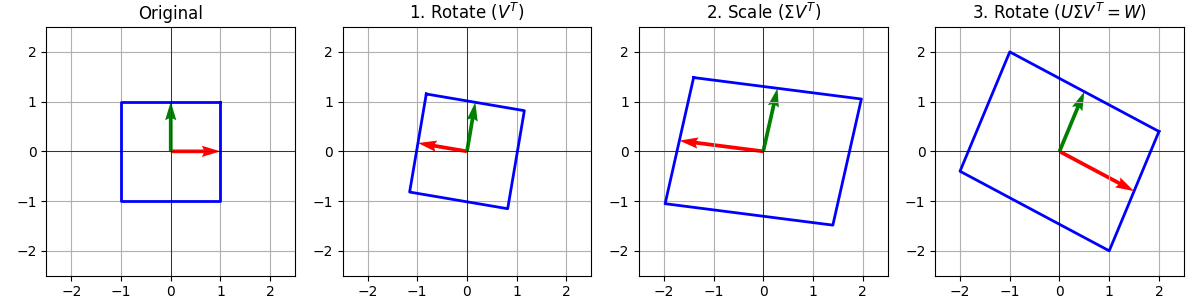

In [18]:
# A random 2x2 weight matrix
W = np.array([[1.5, 0.5], 
              [-0.8, 1.2]])

# Calculate SVD
U, S, V_T = np.linalg.svd(W)
Sigma = np.diag(S)

# Create a square (instead of a circle) so rotations are visually obvious
# Corners of the square: (1,1), (-1,1), (-1,-1), (1,-1), and back to (1,1)
square = np.array([[ 1, -1, -1,  1,  1],
                   [ 1,  1, -1, -1,  1]])

# We also track two orthogonal unit vectors (x and y axes) to clearly see the rotation
vectors = np.array([[1, 0], 
                    [0, 1]])

# Apply transformations step-by-step to both the shape and the vectors
step1_sq = V_T @ square             # First rotation
step2_sq = Sigma @ step1_sq         # Scaling
step3_sq = U @ step2_sq             # Second rotation (Final W * x)

step1_vec = V_T @ vectors
step2_vec = Sigma @ step1_vec
step3_vec = U @ step2_vec

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
titles = ["Original", "1. Rotate ($V^T$)", "2. Scale ($\Sigma V^T$)", "3. Rotate ($U \Sigma V^T = W$)"]
data_sq = [square, step1_sq, step2_sq, step3_sq]
data_vec = [vectors, step1_vec, step2_vec, step3_vec]

for ax, d_sq, d_vec, title in zip(axes, data_sq, data_vec, titles):
    # Plot the bounding shape
    ax.plot(d_sq[0, :], d_sq[1, :], color='blue', linewidth=2)
    
    # Plot the basis vectors as arrows (Red for X-axis, Green for Y-axis)
    ax.quiver(0, 0, d_vec[0, 0], d_vec[1, 0], angles='xy', scale_units='xy', scale=1, color='red', width=0.015)
    ax.quiver(0, 0, d_vec[0, 1], d_vec[1, 1], angles='xy', scale_units='xy', scale=1, color='green', width=0.015)
    
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.show()

## 4. Escaping Saddle Points: GD vs Momentum vs Adam

In high-dimensional networks, a zero gradient ($\nabla L = 0$) almost never means a local minimum; it is almost always a saddle point. 
Let's define a function with a saddle point at $(0,0)$ and minima at $(0, 1)$ and $(0, -1)$: 
$$f(x, y) = x^2 + y^4 - 2y^2$$

We will initialize our optimizers very close to the flat saddle point and see how many steps it takes Vanilla Gradient Descent, Momentum, and Adam to escape it and find the minimum.

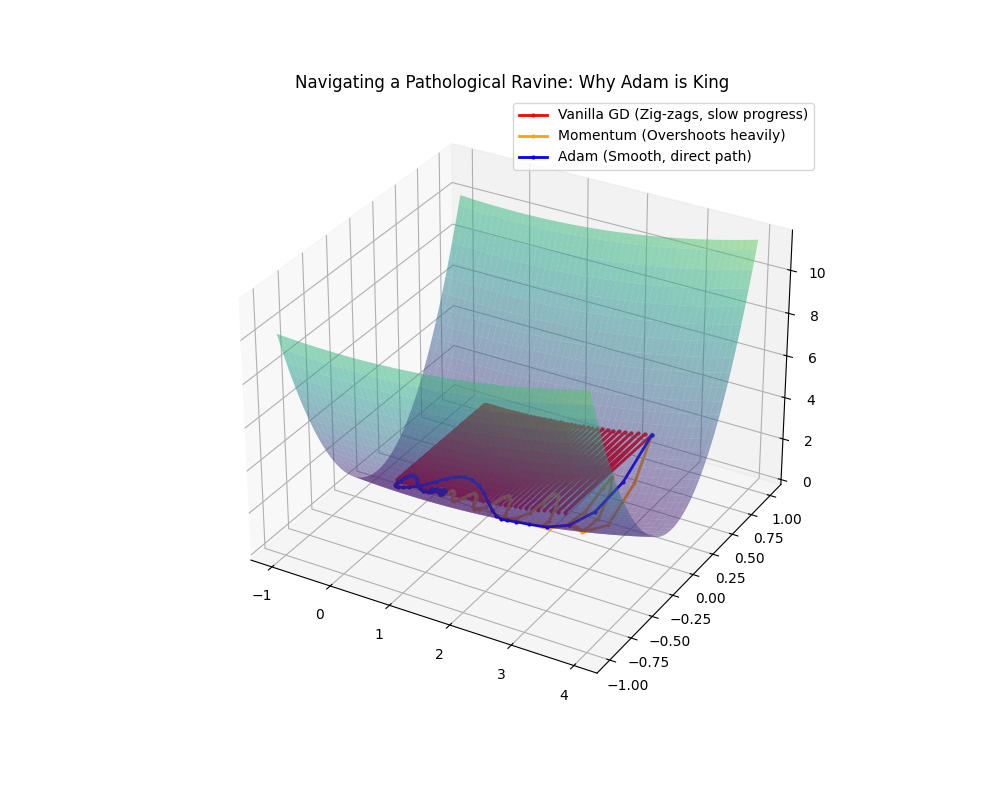

Minimum is at (0.0, 0.0)
------------------------------
Vanilla GD Final Position: (0.1449, 0.5000)
Momentum Final Position:   (0.0001, 0.0000)
Adam Final Position:       (-0.0011, 0.0000)


In [20]:
# Define a highly ill-conditioned Ravine (Elongated Bowl)
# The y-axis is very steep, the x-axis is very flat.
def f(x, y):
    return 0.1 * x**2 + 10 * y**2

def grad_f(x, y):
    # Partial derivatives (dx, dy)
    # Notice the massive difference in scale between x and y gradients
    return np.array([0.2 * x, 20 * y]) 

# Start far out on the flat x-axis, slightly off-center on the steep y-axis
start_pos = np.array([3.0, 0.5])

# We use a learning rate that is safe for GD (anything higher and GD explodes on the y-axis)
learning_rate_gd = 0.1  
# Adam naturally handles larger learning rates because it normalizes the gradients
learning_rate_adam = 0.2 
iterations = 150

# 1. Vanilla Gradient Descent
pos_gd = start_pos.copy()
path_gd = [pos_gd.copy()]
for _ in range(iterations):
    grad = grad_f(pos_gd[0], pos_gd[1])
    pos_gd = pos_gd - learning_rate_gd * grad
    path_gd.append(pos_gd.copy())

# 2. Gradient Descent with Momentum
pos_mom = start_pos.copy()
path_mom = [pos_mom.copy()]
v = np.zeros(2)
beta = 0.9
for _ in range(iterations):
    grad = grad_f(pos_mom[0], pos_mom[1])
    v = beta * v + (1 - beta) * grad 
    pos_mom = pos_mom - learning_rate_gd * v * 2 # Slight scaling for stability
    path_mom.append(pos_mom.copy())

# 3. Adam Optimizer
pos_adam = start_pos.copy()
path_adam = [pos_adam.copy()]
m = np.zeros(2)
v_adam = np.zeros(2)
beta1, beta2, epsilon = 0.9, 0.999, 1e-8
for t in range(1, iterations + 1):
    grad = grad_f(pos_adam[0], pos_adam[1])
    m = beta1 * m + (1 - beta1) * grad
    v_adam = beta2 * v_adam + (1 - beta2) * (grad**2)
    m_hat = m / (1 - beta1**t)
    v_hat = v_adam / (1 - beta2**t)
    pos_adam = pos_adam - learning_rate_adam * m_hat / (np.sqrt(v_hat) + epsilon)
    path_adam.append(pos_adam.copy())

# Plotting the 3D Surface and Paths
# Adjusted meshgrid to fit the new function's perspective
X = np.linspace(-1, 4, 100)
Y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(X, Y)
Z = f(X, Y)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
# We limit the Z axis visual scale so the ravine doesn't look like a solid wall
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5, vmax=15)

# Extract paths for plotting
path_gd = np.array(path_gd)
path_mom = np.array(path_mom)
path_adam = np.array(path_adam)

ax.plot(path_gd[:,0], path_gd[:,1], f(path_gd[:,0], path_gd[:,1]), label='Vanilla GD (Zig-zags, slow progress)', color='red', linewidth=2, marker='o', markersize=2)
ax.plot(path_mom[:,0], path_mom[:,1], f(path_mom[:,0], path_mom[:,1]), label='Momentum (Overshoots heavily)', color='orange', linewidth=2, marker='o', markersize=2)
ax.plot(path_adam[:,0], path_adam[:,1], f(path_adam[:,0], path_adam[:,1]), label='Adam (Smooth, direct path)', color='blue', linewidth=2, marker='o', markersize=2)

ax.set_title("Navigating a Pathological Ravine: Why Adam is King")
ax.legend()
plt.show()

print(f"Minimum is at (0.0, 0.0)")
print("-" * 30)
print(f"Vanilla GD Final Position: ({path_gd[-1][0]:.4f}, {path_gd[-1][1]:.4f})")
print(f"Momentum Final Position:   ({path_mom[-1][0]:.4f}, {path_mom[-1][1]:.4f})")
print(f"Adam Final Position:       ({path_adam[-1][0]:.4f}, {path_adam[-1][1]:.4f})")

In [25]:
import torch

dimensions_to_test = [1, 2, 5, 10, 15, 20]

num_trials = 10000

for d in dimensions_to_test:
    local_min_count = 0

    for _ in range(num_trials):
        A = torch.randn(d, d)
        H = (A + A.T) / 2.0

        eigvals = torch.linalg.eigvalsh(H)

        is_local_min = torch.all(eigvals > 0).item()

        if is_local_min:
            local_min_count += 1

    empirical_p = local_min_count / num_trials
    theoretical_p = 0.5**d

    print(f"Dimensions: {d:2d} | Empricial P: {empirical_p: .8f} | Theoretical P: {theoretical_p: .8f}")

Dimensions:  1 | Empricial P:  0.50720000 | Theoretical P:  0.50000000
Dimensions:  2 | Empricial P:  0.14650000 | Theoretical P:  0.25000000
Dimensions:  5 | Empricial P:  0.00020000 | Theoretical P:  0.03125000
Dimensions: 10 | Empricial P:  0.00000000 | Theoretical P:  0.00097656
Dimensions: 15 | Empricial P:  0.00000000 | Theoretical P:  0.00003052
Dimensions: 20 | Empricial P:  0.00000000 | Theoretical P:  0.00000095
